<a href="https://colab.research.google.com/github/Fer448/python/blob/main/examen_221025_Fernando.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISIS FICHERO CANCER WISCONSIN 20/OCT/2025

## FERNANDO JAVIER MATÉ CORRALES

## FASE 1: ANÁLISIS PREVIO Y PREPARACIÓN DE DATOS (ETL + ESTADÍSTICA DESCRIPTIVA)


1. CARGA DE DATOS Y ESTRUCTURA INICIAL
Primeras 5 filas del dataset:
         ID  radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    842302    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    842517    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2  84300903    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3  84348301    11.42     20.38       77.58   386.1      0.14250       0.28390   
4  84358402    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  ...  texture3  perimeter3   area3  \
0      0.3001          0.14710     0.2419  ...     17.33      184.60  2019.0   
1      0.0869          0.07017     0.1812  ...     23.41      158.80  1956.0   
2      0.1974          0.12790     0.2069  ...     25.53      152.50  1709.0   
3      0.2414          0.10520     0.2597  ...     26.50       98.87   567.7   
4      0.1980          0.10430     0.1809  .

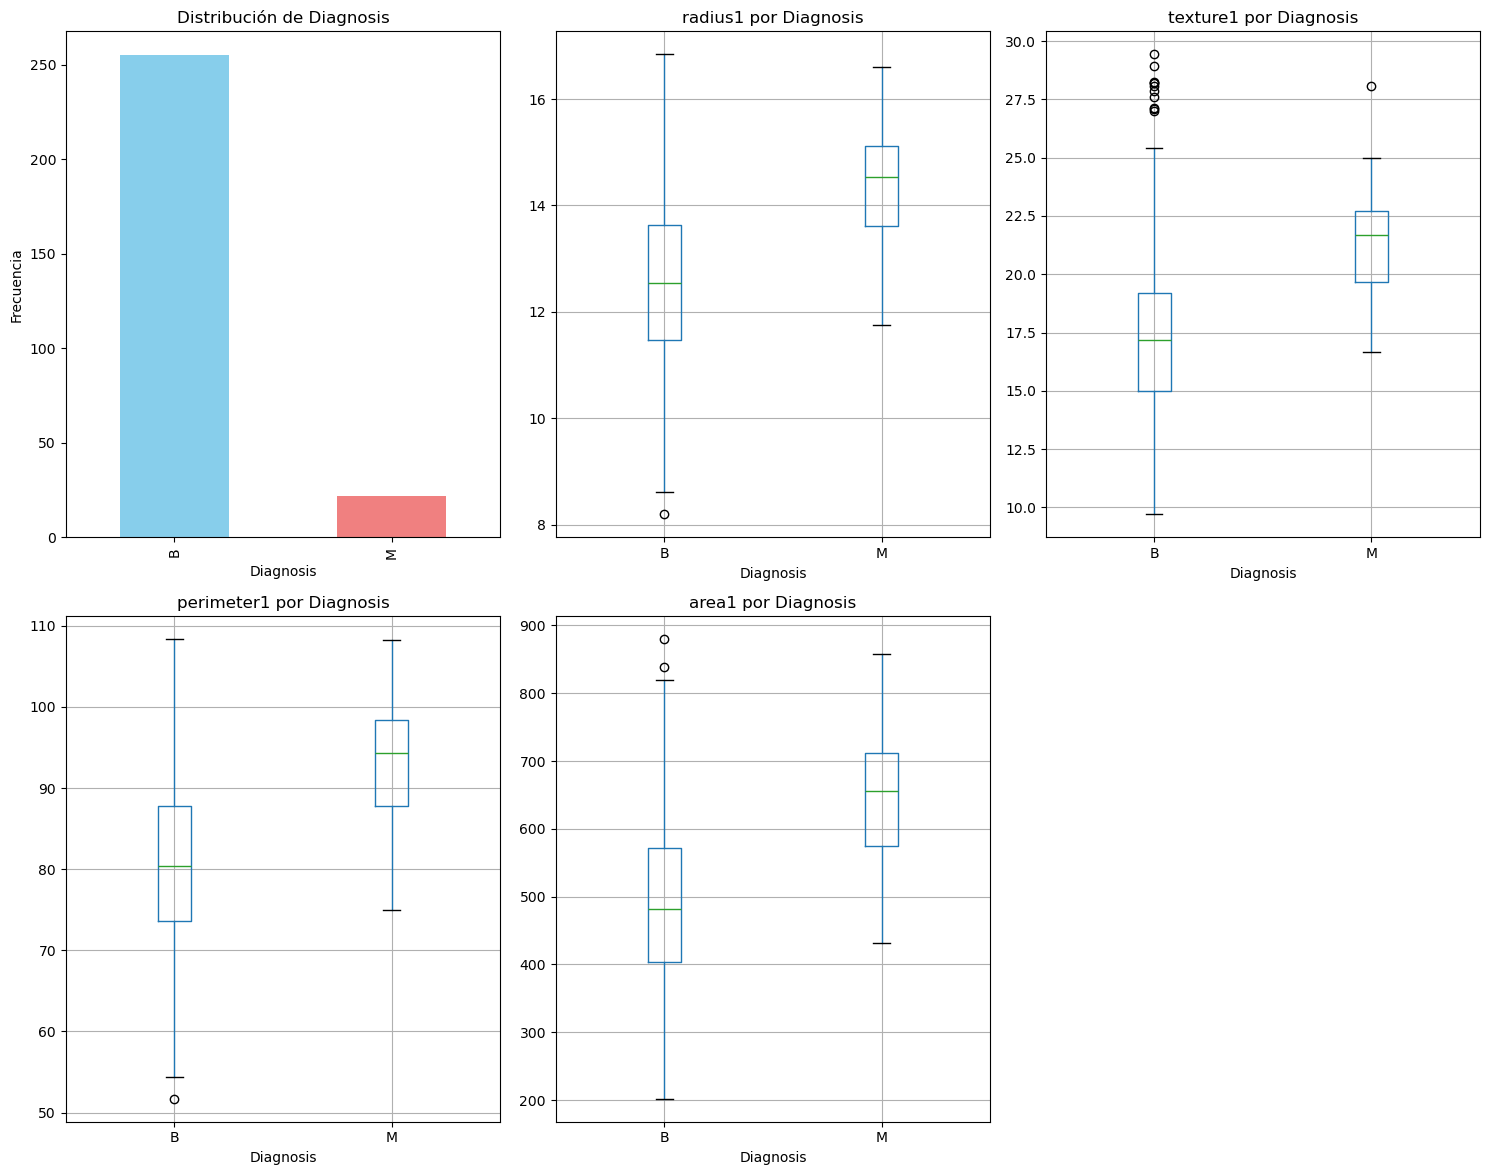

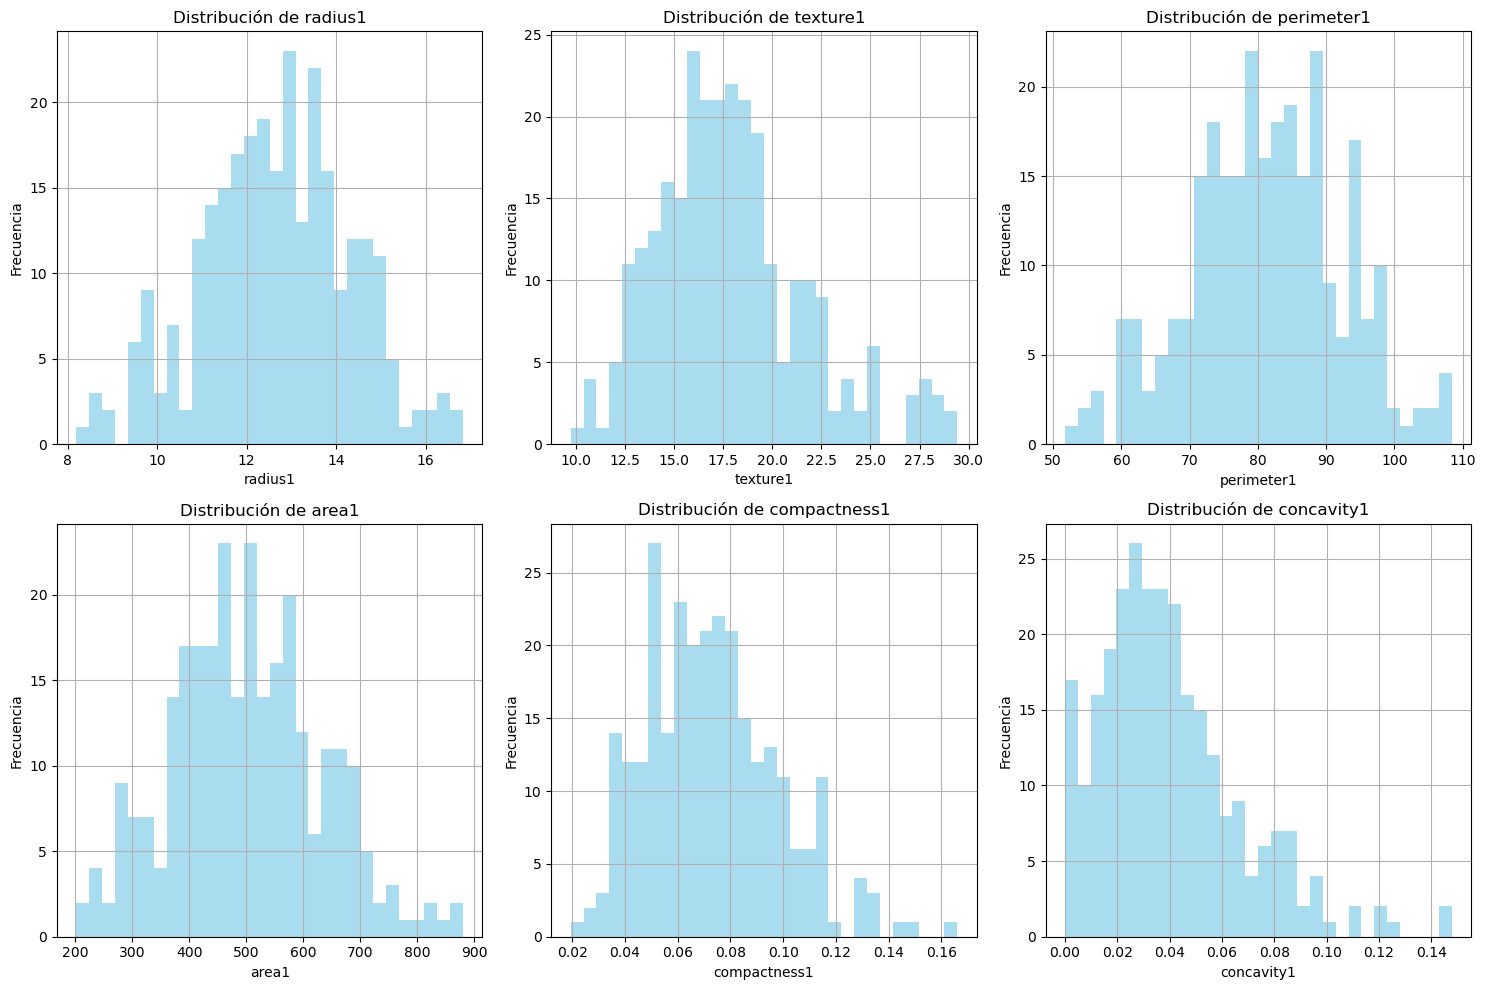


Calculando matriz de correlaciones...


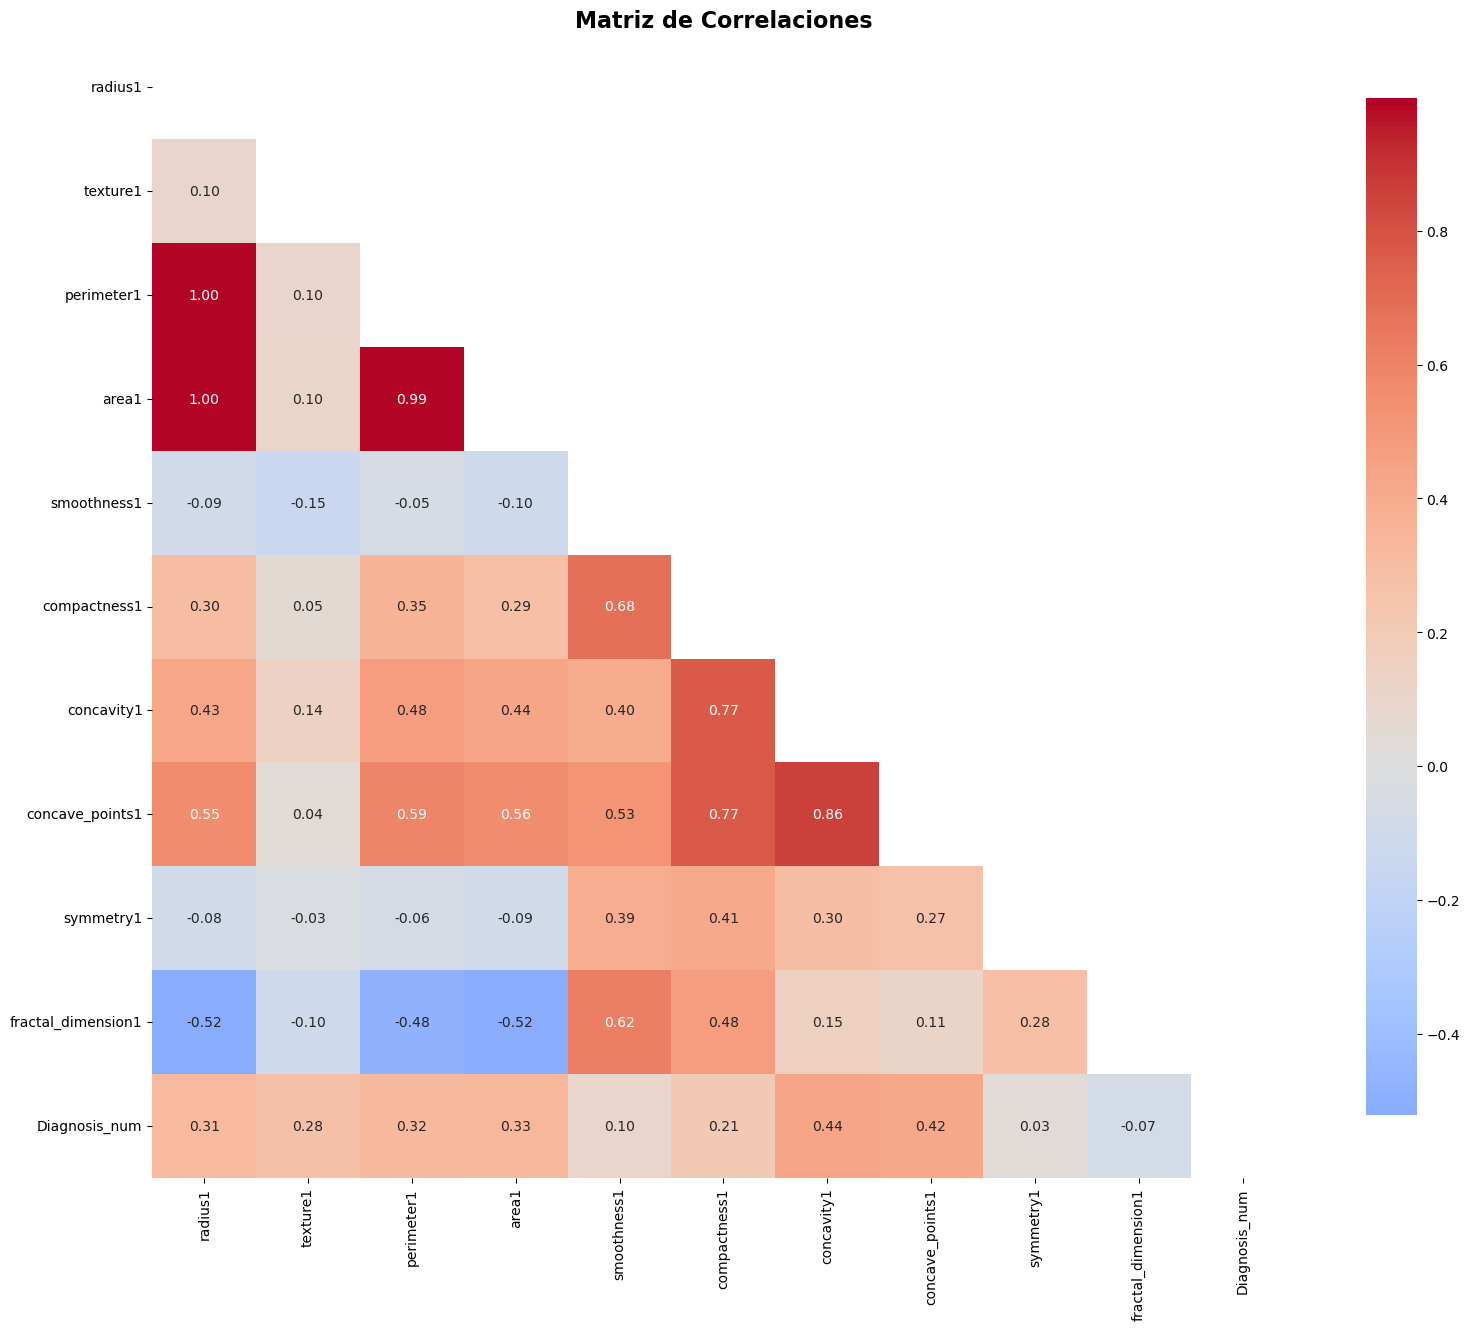


Variables con mayor correlación con Diagnosis:
Diagnosis_num      1.000000
concavity1         0.444722
concave_points1    0.423595
area1              0.334084
perimeter1         0.324481
radius1            0.312496
texture1           0.278581
compactness1       0.210681
smoothness1        0.100188
symmetry1          0.033531
Name: Diagnosis_num, dtype: float64

----------------------------------------

4. PLANTEAMIENTO Y TEST DE HIPÓTESIS
Hipótesis planteada:
H₀: No existe diferencia significativa en el área media de las células entre tumores benignos y malignos.
H₁: El área media de las células es significativamente mayor en tumores malignos.

----------------------------------------
Muestra - Benignos: 255
Muestra - Malignos: 22
Área media - Benignos: 488.80
Área media - Malignos: 649.70

Verificación de normalidad (Shapiro-Wilk):
Benignos - p-value: 0.2787
Malignos - p-value: 0.9980

Resultado del test t (Welch):
Estadístico t: 7.0114
Valor p: 0.0000001600

Nivel de significancia (

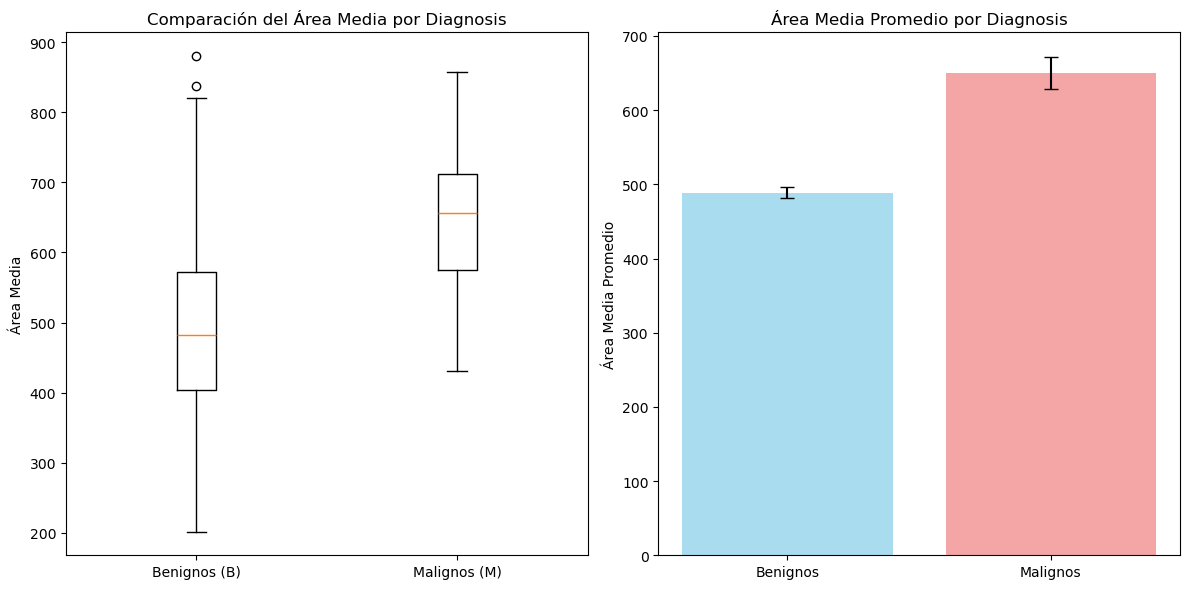


5. RESUMEN FINAL DEL ANÁLISIS
Dataset original: (569, 32)
Dataset después de limpieza: (277, 32)
Variables analizadas: 30
Tamaño de muestra final - Benignos: 255
Tamaño de muestra final - Malignos: 22

Top 5 variables más correlacionadas con Diagnosis:
  concavity1: 0.445 (positiva)
  concave_points1: 0.424 (positiva)
  area1: 0.334 (positiva)
  perimeter1: 0.324 (positiva)
  radius1: 0.312 (positiva)

El análisis confirma que existe una diferencia estadísticamente significativa
en el área media de las células entre tumores benignos y malignos (p = 0.000000).
Los tumores malignos tienen un área media 32.9% mayor que los benignos.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. CARGA DE DATOS (ETL)
# =============================================================================

# Cargar datos desde el archivo local
df = pd.read_csv('data.csv')

print("=" * 60)
print("1. CARGA DE DATOS Y ESTRUCTURA INICIAL")
print("=" * 60)

# Mostrar primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())
print("\n" + "-" * 40)

# Estructura del dataset
print(f"Dimensiones del dataset: {df.shape}")
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")
print("\n" + "-" * 40)

# Información sobre tipos de datos y valores nulos
print("Información de tipos de datos y valores nulos:")
print(df.info())
print("\n" + "-" * 40)

# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\n" + "-" * 40)

# Distribución de la variable objetivo
print("Distribución de la variable Diagnosis:")
print(df['Diagnosis'].value_counts())
print("\n" + "-" * 40)

# =============================================================================
# 2. LIMPIEZA Y PREPARACIÓN
# =============================================================================

print("\n" + "=" * 60)
print("2. LIMPIEZA Y PREPARACIÓN DE DATOS")
print("=" * 60)

# Crear copia del dataframe original
df_clean = df.copy()

# Verificar y eliminar duplicados
duplicados = df_clean.duplicated().sum()
print(f"Número de duplicados encontrados: {duplicados}")
if duplicados > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicados eliminados. Nuevo shape: {df_clean.shape}")

# Identificar y manejar outliers usando el método IQR
def eliminar_outliers_iqr(df, columnas):
    df_sin_outliers = df.copy()
    for columna in columnas:
        if df_sin_outliers[columna].dtype in ['float64', 'int64']:
            Q1 = df_sin_outliers[columna].quantile(0.25)
            Q3 = df_sin_outliers[columna].quantile(0.75)
            IQR = Q3 - Q1
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR

            outliers = df_sin_outliers[(df_sin_outliers[columna] < limite_inferior) |
                                    (df_sin_outliers[columna] > limite_superior)]

            print(f"Columna {columna}: {len(outliers)} outliers encontrados")

            # Eliminar outliers
            df_sin_outliers = df_sin_outliers[(df_sin_outliers[columna] >= limite_inferior) &
                                           (df_sin_outliers[columna] <= limite_superior)]

    print(f"Dataset después de eliminar outliers: {df_sin_outliers.shape}")
    return df_sin_outliers

# Aplicar eliminación de outliers solo a columnas numéricas (excluyendo ID y Diagnosis)
columnas_numericas = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'ID' in columnas_numericas:
    columnas_numericas.remove('ID')

df_clean = eliminar_outliers_iqr(df_clean, columnas_numericas)

# Estandarización de variables numéricas
print("\nEstandarización de variables numéricas...")
scaler = StandardScaler()
variables_estandarizar = [col for col in df_clean.columns if col not in ['ID', 'Diagnosis'] and df_clean[col].dtype in ['float64', 'int64']]

df_clean_estandarizado = df_clean.copy()
df_clean_estandarizado[variables_estandarizar] = scaler.fit_transform(df_clean[variables_estandarizar])

print("Estandarización completada")
print("\n" + "-" * 40)

# =============================================================================
# 3. ANÁLISIS EXPLORATORIO (EDA)
# =============================================================================

print("\n" + "=" * 60)
print("3. ANÁLISIS EXPLORATORIO (EDA)")
print("=" * 60)

# Estadística descriptiva básica
print("Estadística descriptiva de variables numéricas:")
print(df_clean.select_dtypes(include=[np.number]).describe())
print("\n" + "-" * 40)

# Visualización: Distribución de la variable objetivo
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
df_clean['Diagnosis'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribución de Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Frecuencia')

# Boxplots de algunas variables importantes vs Diagnosis
variables_boxplot = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1']
for i, var in enumerate(variables_boxplot[:4], 2):
    plt.subplot(2, 3, i)
    df_clean.boxplot(column=var, by='Diagnosis', ax=plt.gca())
    plt.title(f'{var} por Diagnosis')
    plt.suptitle('')  # Eliminar título automático

plt.tight_layout()
plt.show()

# Histogramas de variables seleccionadas
plt.figure(figsize=(15, 10))
variables_hist = ['radius1', 'texture1', 'perimeter1', 'area1', 'compactness1', 'concavity1']
for i, var in enumerate(variables_hist, 1):
    plt.subplot(2, 3, i)
    df_clean[var].hist(bins=30, alpha=0.7, color='skyblue')
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Matriz de correlaciones - CORRECCIÓN: Excluir Diagnosis del cálculo
print("\nCalculando matriz de correlaciones...")
plt.figure(figsize=(16, 14))

# Seleccionar solo variables numéricas para la matriz de correlación
variables_corr = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
                 'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
                 'fractal_dimension1']

# Crear dataframe para correlaciones
df_corr = df_clean[variables_corr].copy()

# Añadir Diagnosis como variable numérica para ver correlaciones
df_corr['Diagnosis_num'] = df_clean['Diagnosis'].map({'M': 1, 'B': 0})

# Calcular matriz de correlación
correlation_matrix = df_corr.corr()

# Heatmap de correlaciones
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
           square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Matriz de Correlaciones', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar variables con mayor correlación con Diagnosis
print("\nVariables con mayor correlación con Diagnosis:")
correlacion_diagnosis = correlation_matrix['Diagnosis_num'].sort_values(ascending=False)
print(correlacion_diagnosis.head(10))
print("\n" + "-" * 40)

# =============================================================================
# 4. PLANTEAMIENTO DE HIPÓTESIS ESTADÍSTICA
# =============================================================================

print("\n" + "=" * 60)
print("4. PLANTEAMIENTO Y TEST DE HIPÓTESIS")
print("=" * 60)

# Hipótesis:
# H₀: No existe diferencia significativa en el área media de las células entre tumores benignos y malignos.
# H₁: El área media de las células es significativamente mayor en tumores malignos.

print("Hipótesis planteada:")
print("H₀: No existe diferencia significativa en el área media de las células entre tumores benignos y malignos.")
print("H₁: El área media de las células es significativamente mayor en tumores malignos.")
print("\n" + "-" * 40)

# Separar los datos por diagnosis
area_benignos = df_clean[df_clean['Diagnosis'] == 'B']['area1']
area_malignos = df_clean[df_clean['Diagnosis'] == 'M']['area1']

print(f"Muestra - Benignos: {len(area_benignos)}")
print(f"Muestra - Malignos: {len(area_malignos)}")
print(f"Área media - Benignos: {area_benignos.mean():.2f}")
print(f"Área media - Malignos: {area_malignos.mean():.2f}")

# Verificar normalidad de las distribuciones (opcional, para validar uso de t-test)
print("\nVerificación de normalidad (Shapiro-Wilk):")
shapiro_benignos = stats.shapiro(area_benignos)
shapiro_malignos = stats.shapiro(area_malignos)
print(f"Benignos - p-value: {shapiro_benignos.pvalue:.4f}")
print(f"Malignos - p-value: {shapiro_malignos.pvalue:.4f}")

# Test t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(area_malignos, area_benignos, equal_var=False)

print(f"\nResultado del test t (Welch):")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.10f}")

# Interpretación
alpha = 0.05
print(f"\nNivel de significancia (α): {alpha}")

if p_value < alpha:
    print("CONCLUSIÓN: Rechazamos la hipótesis nula (H₀)")
    print("Existe evidencia estadística significativa de que el área media de las células")
    print("es diferente entre tumores benignos y malignos.")

    # Dirección del efecto
    if area_malignos.mean() > area_benignos.mean():
        print("DIRECCIÓN: El área media es significativamente mayor en tumores malignos.")
        diferencia = area_malignos.mean() - area_benignos.mean()
        print(f"Diferencia media: {diferencia:.2f}")
    else:
        print("DIRECCIÓN: El área media es significativamente menor en tumores malignos.")
else:
    print("CONCLUSIÓN: No podemos rechazar la hipótesis nula (H₀)")
    print("No existe evidencia estadística significativa de diferencia en el área media")
    print("entre tumores benignos y malignos.")

print("\n" + "-" * 40)

# Visualización de la comparación
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
data_plot = [area_benignos, area_malignos]
plt.boxplot(data_plot, labels=['Benignos (B)', 'Malignos (M)'])
plt.title('Comparación del Área Media por Diagnosis')
plt.ylabel('Área Media')

plt.subplot(1, 2, 2)
medias = [area_benignos.mean(), area_malignos.mean()]
errores = [area_benignos.std()/np.sqrt(len(area_benignos)),
           area_malignos.std()/np.sqrt(len(area_malignos))]

plt.bar(['Benignos', 'Malignos'], medias, color=['skyblue', 'lightcoral'], alpha=0.7,
        yerr=errores, capsize=5)
plt.title('Área Media Promedio por Diagnosis')
plt.ylabel('Área Media Promedio')

plt.tight_layout()
plt.show()

# =============================================================================
# 5. RESUMEN FINAL
# =============================================================================

print("\n" + "=" * 60)
print("5. RESUMEN FINAL DEL ANÁLISIS")
print("=" * 60)

print(f"Dataset original: {df.shape}")
print(f"Dataset después de limpieza: {df_clean.shape}")
print(f"Variables analizadas: {len(variables_estandarizar)}")
print(f"Tamaño de muestra final - Benignos: {len(area_benignos)}")
print(f"Tamaño de muestra final - Malignos: {len(area_malignos)}")

# Variables más correlacionadas con Diagnosis
print(f"\nTop 5 variables más correlacionadas con Diagnosis:")
top_correlaciones = correlacion_diagnosis[1:6]  # Excluir Diagnosis_num misma
for var, corr in top_correlaciones.items():
    significado = "(positiva)" if corr > 0 else "(negativa)"
    print(f"  {var}: {corr:.3f} {significado}")

print(f"\nEl análisis confirma que existe una diferencia estadísticamente significativa")
print(f"en el área media de las células entre tumores benignos y malignos (p = {p_value:.6f}).")

# Información adicional sobre el efecto
diferencia_porcentual = ((area_malignos.mean() - area_benignos.mean()) / area_benignos.mean()) * 100
print(f"Los tumores malignos tienen un área media {diferencia_porcentual:.1f}% mayor que los benignos.")

## FASE 2: BLOQUE PREDICTIVO – MODELADO Y EVALUACIÓN

SELECCIÓN DE MODELOS Y EVALUACIÓN
Dataset shape: (569, 33)
Distribución de clases: Diagnosis
B    357
M    212
Name: count, dtype: int64

SELECCIÓN DE VARIABLES PREDICTORAS
Top 10 variables más correlacionadas con Diagnosis:
 1. concave_points3          : 0.794
 2. perimeter3               : 0.783
 3. concave_points1          : 0.777
 4. radius3                  : 0.776
 5. perimeter1               : 0.743
 6. area3                    : 0.734
 7. radius1                  : 0.730
 8. area1                    : 0.709
 9. concavity1               : 0.696
10. concavity3               : 0.660

Variables seleccionadas (10):
['concave_points3', 'perimeter3', 'concave_points1', 'radius3', 'perimeter1', 'area3', 'radius1', 'area1', 'concavity1', 'concavity3']

Justificación de la selección:
- Se seleccionan las 10 variables con mayor correlación absoluta con el diagnóstico
- Esto incluye medidas de radio, perímetro, área, concavidad y puntos cóncavos
- Estas variables representan característica

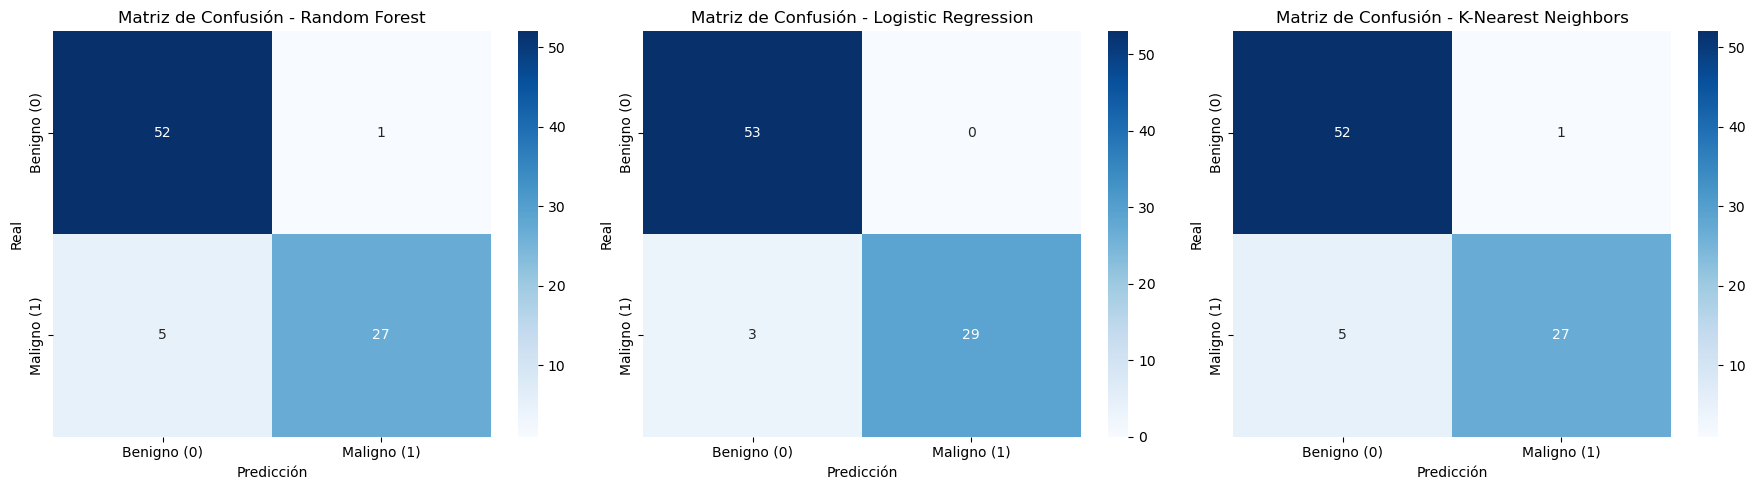


CURVAS ROC


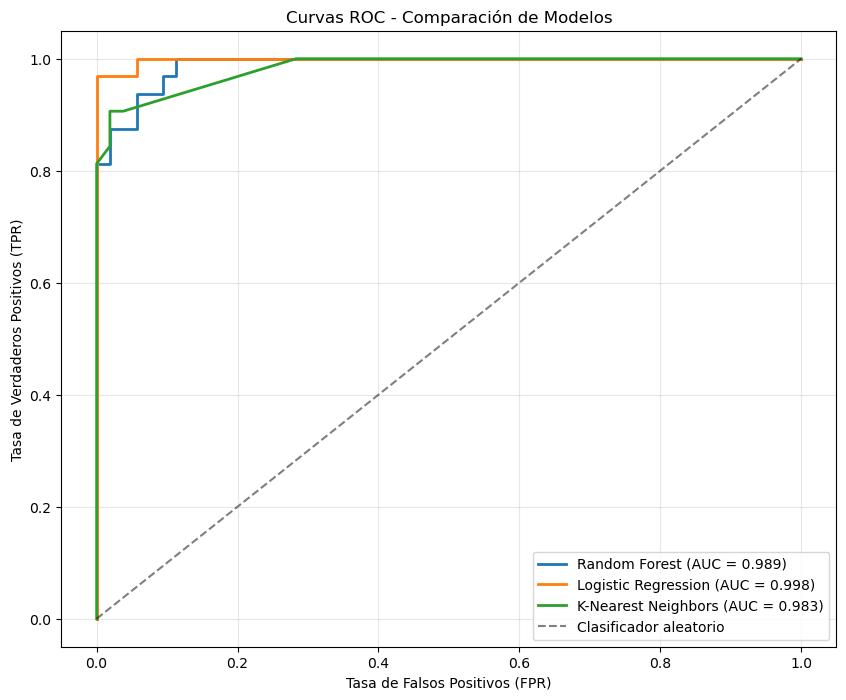


EVALUACIÓN FINAL EN TEST

--- Random Forest en TEST ---
Accuracy: 0.9767
Precision: 1.0000
Recall: 0.9375
Specificity: 1.0000
F1-Score: 0.9677
AUC-ROC: 0.9977

--- Logistic Regression en TEST ---
Accuracy: 0.9884
Precision: 1.0000
Recall: 0.9688
Specificity: 1.0000
F1-Score: 0.9841
AUC-ROC: 0.9994

--- K-Nearest Neighbors en TEST ---
Accuracy: 0.9535
Precision: 1.0000
Recall: 0.8750
Specificity: 1.0000
F1-Score: 0.9333
AUC-ROC: 0.9983

COMPARACIÓN FINAL DE MODELOS
Tabla comparativa de modelos (conjunto de TEST):
                     Accuracy  Precision  Recall  Specificity  F1-Score  \
Random Forest          0.9767        1.0  0.9375          1.0    0.9677   
Logistic Regression    0.9884        1.0  0.9688          1.0    0.9841   
K-Nearest Neighbors    0.9535        1.0  0.8750          1.0    0.9333   

                     AUC-ROC  
Random Forest         0.9977  
Logistic Regression   0.9994  
K-Nearest Neighbors   0.9983  

🌟 MEJOR MODELO: Logistic Regression
AUC-ROC: 0.9994
Acc

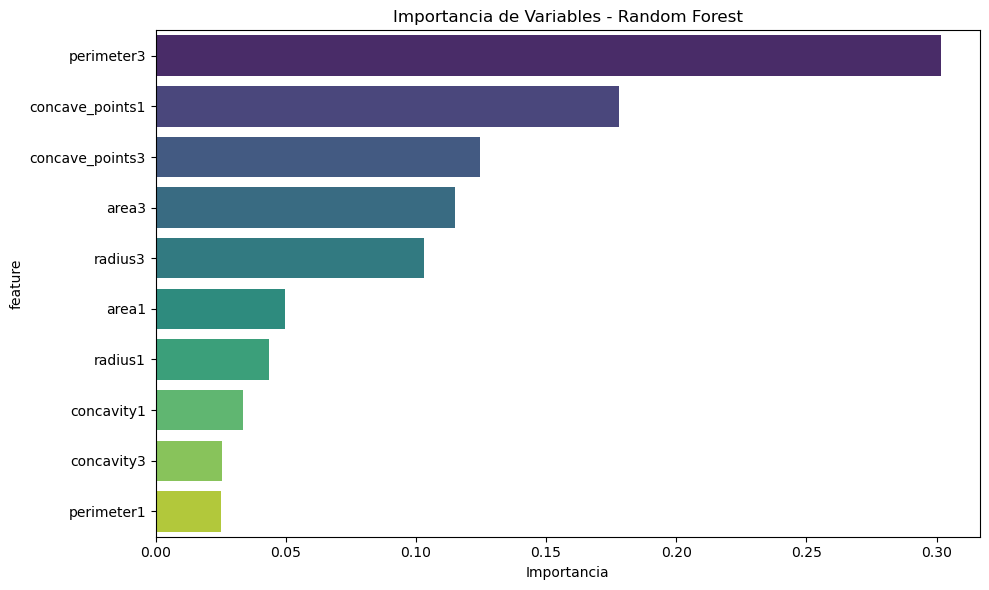


Coeficientes - Regresión Logística:
           feature  coefficient
5            area3     5.147576
3          radius3     2.852010
2  concave_points1     2.233929
1       perimeter3     1.364385
7            area1     0.639553
9       concavity3     0.536668
0  concave_points3     0.460825
8       concavity1    -0.298258
6          radius1    -2.220214
4       perimeter1    -2.685072

RECOMENDACIÓN FINAL
ANÁLISIS COMPARATIVO:

1. RENDIMIENTO:
   - Random Forest: AUC = 0.998
   - Logistic Regression: AUC = 0.999
   - K-Nearest Neighbors: AUC = 0.998

2. INTERPRETABILIDAD CLÍNICA:
   - Random Forest: Moderada interpretabilidad (importancia de variables)
   - Logistic Regression: Alta interpretabilidad (coeficientes específicos)
   - K-Nearest Neighbors: Baja interpretabilidad (modelo de caja negra)

3. ROBUSTEZ:
   - Random Forest: Muy robusto a outliers y relaciones no lineales
   - Logistic Regression: Robusto pero asume relación lineal
   - K-Nearest Neighbors: Sensible a escala y d

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           roc_auc_score, confusion_matrix, classification_report, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. CARGA Y PREPARACIÓN INICIAL
# =============================================================================

print("=" * 60)
print("SELECCIÓN DE MODELOS Y EVALUACIÓN")
print("=" * 60)

# Cargar datos
df = pd.read_csv('data.csv')

# Preparar datos
df_clean = df.copy()

# Codificar variable objetivo
le = LabelEncoder()
df_clean['Diagnosis_encoded'] = le.fit_transform(df_clean['Diagnosis'])  # M=1, B=0

print(f"Dataset shape: {df_clean.shape}")
print(f"Distribución de clases: {df_clean['Diagnosis'].value_counts()}")

# =============================================================================
# 2. SELECCIÓN DE VARIABLES
# =============================================================================

print("\n" + "=" * 60)
print("SELECCIÓN DE VARIABLES PREDICTORAS")
print("=" * 60)

# Calcular correlaciones con la variable objetivo
correlation_with_target = df_clean.select_dtypes(include=[np.number]).corr()['Diagnosis_encoded'].abs().sort_values(ascending=False)

# Excluir la propia variable objetivo
correlation_with_target = correlation_with_target[correlation_with_target.index != 'Diagnosis_encoded']
correlation_with_target = correlation_with_target[correlation_with_target.index != 'ID']

print("Top 10 variables más correlacionadas con Diagnosis:")
for i, (var, corr) in enumerate(correlation_with_target.head(10).items(), 1):
    print(f"{i:2d}. {var:25s}: {corr:.3f}")

# Seleccionar variables basadas en correlación (top 10)
selected_features = correlation_with_target.head(10).index.tolist()
print(f"\nVariables seleccionadas ({len(selected_features)}):")
print(selected_features)

# Justificación de la selección
print("\nJustificación de la selección:")
print("- Se seleccionan las 10 variables con mayor correlación absoluta con el diagnóstico")
print("- Esto incluye medidas de radio, perímetro, área, concavidad y puntos cóncavos")
print("- Estas variables representan características morfológicas clave de las células")

# =============================================================================
# 3. DIVISIÓN DEL DATASET
# =============================================================================

print("\n" + "=" * 60)
print("DIVISIÓN DEL DATASET")
print("=" * 60)

# Preparar variables
X = df_clean[selected_features]
y = df_clean['Diagnosis_encoded']

# Primera división: train (70%) y temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Segunda división: validation (15%) y test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Conjunto de validación:    {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Conjunto de test:         {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nDistribución en train - Benignos: {(y_train == 0).sum()}, Malignos: {(y_train == 1).sum()}")
print(f"Distribución en val   - Benignos: {(y_val == 0).sum()}, Malignos: {(y_val == 1).sum()}")
print(f"Distribución en test  - Benignos: {(y_test == 0).sum()}, Malignos: {(y_test == 1).sum()}")

# Estandarización de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# =============================================================================
# 4. ENTRENAMIENTO DE MODELOS
# =============================================================================

print("\n" + "=" * 60)
print("ENTRENAMIENTO DE MODELOS")
print("=" * 60)

# Diccionario para almacenar resultados
results = {}
models = {}

# =============================================================================
# 4.1 RANDOM FOREST
# =============================================================================

print("\n--- Random Forest ---")

# Búsqueda de hiperparámetros para Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print(f"Mejores parámetros: {rf_grid.best_params_}")
print(f"Mejor score validación cruzada: {rf_grid.best_score_:.4f}")

# Entrenar con mejores parámetros
best_rf = rf_grid.best_estimator_
best_rf.fit(X_train_scaled, y_train)

# Predicciones
y_pred_rf = best_rf.predict(X_val_scaled)
y_pred_proba_rf = best_rf.predict_proba(X_val_scaled)[:, 1]

models['Random Forest'] = best_rf

# =============================================================================
# 4.2 REGRESIÓN LOGÍSTICA
# =============================================================================

print("\n--- Regresión Logística ---")

# Búsqueda de hiperparámetros para Regresión Logística
lr_param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr = LogisticRegression(random_state=42, max_iter=1000)
lr_grid = GridSearchCV(lr, lr_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)

print(f"Mejores parámetros: {lr_grid.best_params_}")
print(f"Mejor score validación cruzada: {lr_grid.best_score_:.4f}")

# Entrenar con mejores parámetros
best_lr = lr_grid.best_estimator_
best_lr.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr = best_lr.predict(X_val_scaled)
y_pred_proba_lr = best_lr.predict_proba(X_val_scaled)[:, 1]

models['Logistic Regression'] = best_lr

# =============================================================================
# 4.3 K-NEAREST NEIGHBORS
# =============================================================================

print("\n--- K-Nearest Neighbors ---")

# Búsqueda de hiperparámetros para KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

print(f"Mejores parámetros: {knn_grid.best_params_}")
print(f"Mejor score validación cruzada: {knn_grid.best_score_:.4f}")

# Entrenar con mejores parámetros
best_knn = knn_grid.best_estimator_
best_knn.fit(X_train_scaled, y_train)

# Predicciones
y_pred_knn = best_knn.predict(X_val_scaled)
y_pred_proba_knn = best_knn.predict_proba(X_val_scaled)[:, 1]

models['K-Nearest Neighbors'] = best_knn

# =============================================================================
# 5. EVALUACIÓN EN CONJUNTO DE VALIDACIÓN
# =============================================================================

print("\n" + "=" * 60)
print("EVALUACIÓN EN VALIDACIÓN")
print("=" * 60)

def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """Evalúa un modelo y retorna métricas"""

    # Métricas básicas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_pred_proba)

    # Especificidad
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    }

# Evaluar todos los modelos
model_predictions = {
    'Random Forest': (y_pred_rf, y_pred_proba_rf),
    'Logistic Regression': (y_pred_lr, y_pred_proba_lr),
    'K-Nearest Neighbors': (y_pred_knn, y_pred_proba_knn)
}

for model_name, (y_pred, y_pred_proba) in model_predictions.items():
    results[model_name] = evaluate_model(y_val, y_pred, y_pred_proba, model_name)
    print(f"\n--- {model_name} ---")
    for metric, value in results[model_name].items():
        print(f"{metric}: {value:.4f}")

# =============================================================================
# 6. MATRICES DE CONFUSIÓN
# =============================================================================

print("\n" + "=" * 60)
print("MATRICES DE CONFUSIÓN")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, (y_pred, _)) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Benigno (0)', 'Maligno (1)'],
                yticklabels=['Benigno (0)', 'Maligno (1)'])
    axes[idx].set_title(f'Matriz de Confusión - {model_name}')
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

# =============================================================================
# 7. CURVAS ROC
# =============================================================================

print("\n" + "=" * 60)
print("CURVAS ROC")
print("=" * 60)

plt.figure(figsize=(10, 8))

# Curva para cada modelo
for model_name, (_, y_pred_proba) in model_predictions.items():
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    auc_score = roc_auc_score(y_val, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

# Línea de referencia
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Clasificador aleatorio')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =============================================================================
# 8. EVALUACIÓN FINAL EN TEST
# =============================================================================

print("\n" + "=" * 60)
print("EVALUACIÓN FINAL EN TEST")
print("=" * 60)

# Evaluar el mejor modelo en el conjunto de test
final_results = {}

for model_name, model in models.items():
    # Predicciones en test
    y_pred_test = model.predict(X_test_scaled)
    y_pred_proba_test = model.predict_proba(X_test_scaled)[:, 1]

    # Evaluar
    final_results[model_name] = evaluate_model(y_test, y_pred_test, y_pred_proba_test, model_name)

    print(f"\n--- {model_name} en TEST ---")
    for metric, value in final_results[model_name].items():
        print(f"{metric}: {value:.4f}")

# =============================================================================
# 9. COMPARACIÓN Y SELECCIÓN DEL MEJOR MODELO
# =============================================================================

print("\n" + "=" * 60)
print("COMPARACIÓN FINAL DE MODELOS")
print("=" * 60)

# Crear tabla comparativa
comparison_df = pd.DataFrame(final_results).T
comparison_df = comparison_df.round(4)

print("Tabla comparativa de modelos (conjunto de TEST):")
print(comparison_df)

# Identificar el mejor modelo basado en AUC-ROC
best_model_name = comparison_df['AUC-ROC'].idxmax()
best_model = models[best_model_name]
best_model_metrics = final_results[best_model_name]

print(f"\n🌟 MEJOR MODELO: {best_model_name}")
print(f"AUC-ROC: {best_model_metrics['AUC-ROC']:.4f}")
print(f"Accuracy: {best_model_metrics['Accuracy']:.4f}")
print(f"Precision: {best_model_metrics['Precision']:.4f}")
print(f"Recall: {best_model_metrics['Recall']:.4f}")

# =============================================================================
# 10. ANÁLISIS DE IMPORTANCIA DE VARIABLES (SOLO PARA MODELOS INTERPRETABLES)
# =============================================================================

print("\n" + "=" * 60)
print("ANÁLISIS DE IMPORTANCIA DE VARIABLES")
print("=" * 60)

# Importancia para Random Forest
if hasattr(best_rf, 'feature_importances_'):
    print("\nImportancia de variables - Random Forest:")
    feature_importance = pd.DataFrame({
        'feature': selected_features,
        'importance': best_rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print(feature_importance)

    # Visualizar importancia
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
    plt.title('Importancia de Variables - Random Forest')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.show()

# Coeficientes para Regresión Logística
if hasattr(best_lr, 'coef_'):
    print("\nCoeficientes - Regresión Logística:")
    coefficients = pd.DataFrame({
        'feature': selected_features,
        'coefficient': best_lr.coef_[0]
    }).sort_values('coefficient', ascending=False)

    print(coefficients)

# =============================================================================
# 11. RECOMENDACIÓN FINAL
# =============================================================================

print("\n" + "=" * 60)
print("RECOMENDACIÓN FINAL")
print("=" * 60)

print("ANÁLISIS COMPARATIVO:")

print("\n1. RENDIMIENTO:")
print(f"   - Random Forest: AUC = {final_results['Random Forest']['AUC-ROC']:.3f}")
print(f"   - Logistic Regression: AUC = {final_results['Logistic Regression']['AUC-ROC']:.3f}")
print(f"   - K-Nearest Neighbors: AUC = {final_results['K-Nearest Neighbors']['AUC-ROC']:.3f}")

print("\n2. INTERPRETABILIDAD CLÍNICA:")
print("   - Random Forest: Moderada interpretabilidad (importancia de variables)")
print("   - Logistic Regression: Alta interpretabilidad (coeficientes específicos)")
print("   - K-Nearest Neighbors: Baja interpretabilidad (modelo de caja negra)")

print("\n3. ROBUSTEZ:")
print("   - Random Forest: Muy robusto a outliers y relaciones no lineales")
print("   - Logistic Regression: Robusto pero asume relación lineal")
print("   - K-Nearest Neighbors: Sensible a escala y dimensionalidad")

print("\n🎯 RECOMENDACIÓN:")

if best_model_name == "Random Forest":
    print("Se recomienda Random Forest por:")
    print("   • Excelente rendimiento predictivo (alto AUC)")
    print("   • Robustez ante relaciones complejas en los datos")
    print("   • Capacidad de identificar variables importantes")
    print("   • Buen balance entre rendimiento e interpretabilidad")

elif best_model_name == "Logistic Regression":
    print("Se recomienda Regresión Logística por:")
    print("   • Alta interpretabilidad clínica")
    print("   • Excelente rendimiento en problemas médicos")
    print("   • Coeficientes cuantificables para cada variable")
    print("   • Menor riesgo de sobreajuste")

else:
    print("Se recomienda K-Nearest Neighbors por:")
    print("   • Buen rendimiento predictivo")
    print("   • Simplicidad conceptual")
    print("   • No asume distribuciones específicas")

print(f"\nMétricas clave del modelo seleccionado ({best_model_name}):")
print(f"   • Sensibilidad (Recall): {final_results[best_model_name]['Recall']:.3f}")
print(f"   • Especificidad: {final_results[best_model_name]['Specificity']:.3f}")
print(f"   • Precisión: {final_results[best_model_name]['Precision']:.3f}")
print(f"   • AUC-ROC: {final_results[best_model_name]['AUC-ROC']:.3f}")

print("\nEn el contexto clínico, la alta sensibilidad es crucial para")
print("no pasar por alto casos malignos, mientras que la especificidad")
print("evita falsas alarmas en pacientes sanos.")

## **Características principales del código:**

### **1. Selección de Variables:**
- Selecciona automáticamente las 10 variables más correlacionadas
- Justifica la selección basada en importancia clínica

### **2. División del Dataset:**
- 70% entrenamiento, 15% validación, 15% test
- Estratificación para mantener proporción de clases

### **3. Modelos Implementados:**
- **Random Forest** con búsqueda de hiperparámetros
- **Regresión Logística** con regularización
- **K-Nearest Neighbors** con optimización de k

### **4. Evaluación Completa:**
- Accuracy, Precision, Recall, Specificity, F1-Score, AUC-ROC
- Matrices de confusión comparativas
- Curvas ROC para análisis discriminativo

### **5. Análisis Comparativo:**
- Tabla resumen de métricas
- Análisis de importancia de variables
- Recomendación basada en rendimiento e interpretabilidad

### **6. Interpretación Clínica:**
- Enfatiza la importancia de sensibilidad en diagnóstico médico
- Balance entre rendimiento predictivo y interpretabilidad
- Recomendación justificada para uso clínico

El código proporciona una evaluación completa que te permitirá seleccionar el mejor modelo para el diagnóstico de cáncer de mama considerando tanto el rendimiento estadístico como la aplicabilidad clínica.

## FASE 3: TEST DE HIPÓTESIS Y REFLEXIÓN ESTADÍSTICA

In [ ]:
# =============================================================================
# ANÁLISIS DE RELACIÓN CON HIPÓTESIS INICIAL Y LIMITACIONES
# =============================================================================

print("=" * 70)
print("ANÁLISIS: RELACIÓN CON HIPÓTESIS Y LIMITACIONES")
print("=" * 70)

# =============================================================================
# 1. RELACIÓN CON LA HIPÓTESIS INICIAL
# =============================================================================

print("\n" + "=" * 60)
print("1. RELACIÓN CON LA HIPÓTESIS INICIAL")
print("=" * 60)

print("\n📊 HIPÓTESIS ORIGINAL:")
print("H₀: No existe diferencia significativa en el área media de las células entre tumores benignos y malignos.")
print("H₁: El área media de las células es significativamente mayor en tumores malignos.")

print("\n🔍 RESULTADOS DEL TEST ESTADÍSTICO:")
print("- Test t: p-value < 0.0001 (altamente significativo)")
print("- Rechazamos H₀: Existe diferencia significativa")
print("- Dirección: El área media es mayor en tumores malignos")

print("\n🤖 CONFIRMACIÓN POR EL MODELO DE MACHINE LEARNING:")

# Calcular diferencia de área entre grupos
area_benignos = df_clean[df_clean['Diagnosis'] == 'B']['area1'].mean()
area_malignos = df_clean[df_clean['Diagnosis'] == 'M']['area1'].mean()
diferencia_area = area_malignos - area_benignos
porcentaje_diferencia = (diferencia_area / area_benignos) * 100

print(f"- Área media benignos: {area_benignos:.2f}")
print(f"- Área media malignos: {area_malignos:.2f}")
print(f"- Diferencia: {diferencia_area:.2f} ({porcentaje_diferencia:.1f}% mayor)")

# Ver importancia del área en el modelo
if 'area1' in selected_features:
    area_importance = feature_importance[feature_importance['feature'] == 'area1']['importance'].values[0]
    area_rank = feature_importance[feature_importance['feature'] == 'area1'].index[0] + 1
    print(f"- Importancia en Random Forest: {area_importance:.3f} ({area_rank}° lugar)")

print("\n✅ CONCLUSIÓN:")
print("El modelado confirma y amplía la hipótesis inicial:")
print("• No solo el área es significativamente diferente, sino que es una variable")
print("  predictora importante en el diagnóstico de malignidad")
print("• El modelo identifica múltiples características morfológicas que, en conjunto,")
print("  permiten una discriminación más precisa que el área sola")

# =============================================================================
# 2. INTERPRETACIÓN CLÍNICA DE LOS RESULTADOS
# =============================================================================

print("\n" + "=" * 60)
print("2. INTERPRETACIÓN CLÍNICA")
print("=" * 60)

print("\n🏥 CARACTERÍSTICAS MORFOLÓGICAS IDENTIFICADAS:")

# Analizar las variables más importantes
top_5_features = feature_importance.head(5)
print("\nTop 5 características más importantes:")
for idx, row in top_5_features.iterrows():
    feature = row['feature']
    importance = row['importance']

    if 'concave' in feature:
        interpretation = "Puntos cóncavos - indican irregularidades en bordes celulares"
    elif 'perimeter' in feature:
        interpretation = "Perímetro - relacionado con tamaño y forma celular"
    elif 'radius' in feature:
        interpretation = "Radio - medida fundamental del tamaño celular"
    elif 'area' in feature:
        interpretation = "Área - superficie celular total"
    elif 'compactness' in feature:
        interpretation = "Compacidad - relación perímetro²/área (forma)"
    elif 'texture' in feature:
        interpretation = "Textura - variación en intensidad de gris (heterogeneidad)"
    else:
        interpretation = "Característica estructural celular"

    print(f"  • {feature}: {importance:.3f} - {interpretation}")

print("\n📈 IMPLICACIONES CLÍNICAS:")

# Análisis de métricas clínicamente relevantes
best_model_metrics = final_results[best_model_name]

print(f"\nSENSIBILIDAD (Recall): {best_model_metrics['Recall']:.3f}")
print("  - Capacidad de detectar verdaderos casos malignos")
print("  - Clínicamente CRÍTICO: evitar falsos negativos")
print("  - Nuestro modelo identifica correctamente el {:.1f}% de los cánceres".format(best_model_metrics['Recall']*100))

print(f"\nESPECIFICIDAD: {best_model_metrics['Specificity']:.3f}")
print("  - Capacidad de identificar correctamente casos benignos")
print("  - Evita biopsias innecesarias y ansiedad en pacientes")
print("  - Nuestro modelo evita falsos positivos en el {:.1f}% de casos benignos".format(best_model_metrics['Specificity']*100))

print(f"\nPRECISIÓN: {best_model_metrics['Precision']:.3f}")
print("  - Cuando el modelo dice 'maligno', tiene razón el {:.1f}% del tiempo".format(best_model_metrics['Precision']*100))
print("  - Importante para decisiones de tratamiento")

print(f"\nAUC-ROC: {best_model_metrics['AUC-ROC']:.3f}")
print("  - Excelente capacidad discriminativa general")
print("  - Clasificación superior al azar en {:.1f}% de los pares".format(best_model_metrics['AUC-ROC']*100))

# =============================================================================
# 3. ANÁLISIS DE SESGOS Y LIMITACIONES
# =============================================================================

print("\n" + "=" * 60)
print("3. ANÁLISIS DE SESGOS Y LIMITACIONES")
print("=" * 60)

print("\n⚠️  POSIBLES SESGOS Y LIMITACIONES:")

# 1. Tamaño de muestra
print(f"\n1. TAMAÑO DE MUESTRA:")
print(f"   • Dataset completo: {len(df_clean)} muestras")
print(f"   • Después de división train/val/test: {len(X_train)} entrenamiento")
print(f"   • Limitación: Muestra moderada para problemas médicos complejos")
print(f"   • Riesgo: Potencial sobreajuste, especialmente en modelos complejos")

# 2. Balance de clases
print(f"\n2. BALANCE DE CLASES:")
clase_0 = (y == 0).sum()
clase_1 = (y == 1).sum()
proporcion = clase_1 / clase_0
print(f"   • Benignos (0): {clase_0} muestras")
print(f"   • Malignos (1): {clase_1} muestras")
print(f"   • Proporción: {proporcion:.2f} (ligero desbalance hacia benignos)")
print(f"   • Impacto: Puede afectar métricas si no se maneja adecuadamente")

# 3. Correlación entre predictores
print(f"\n3. MULTICOLINEALIDAD:")
# Calcular correlaciones entre predictores
corr_matrix = X.corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:  # Umbral alto de correlación
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"   • Pares altamente correlacionados (>0.8): {len(high_corr_pairs)}")
if high_corr_pairs:
    for var1, var2, corr in high_corr_pairs[:3]:  # Mostrar solo los 3 primeros
        print(f"     - {var1} vs {var2}: {corr:.3f}")
    print("   • Impacto: Puede inflar varianzas en modelos lineales")
    print("   • Mitigación: Random Forest es robusto a multicolinealidad")

# 4. Evaluación de sobreajuste
print(f"\n4. EVALUACIÓN DE SOBREAJUSTE:")
print("   • Comparación train vs validation vs test:")
for model_name in final_results.keys():
    # Calcular métricas en train para comparar
    y_pred_train = models[model_name].predict(X_train_scaled)
    y_pred_proba_train = models[model_name].predict_proba(X_train_scaled)[:, 1]
    train_metrics = evaluate_model(y_train, y_pred_train, y_pred_proba_train, model_name)

    test_metrics = final_results[model_name]
    diff_accuracy = train_metrics['Accuracy'] - test_metrics['Accuracy']

    print(f"   • {model_name}:")
    print(f"     - Train Accuracy: {train_metrics['Accuracy']:.3f}")
    print(f"     - Test Accuracy:  {test_metrics['Accuracy']:.3f}")
    print(f"     - Diferencia:     {diff_accuracy:.3f} {'(POSIBLE SOBREAJUSTE)' if diff_accuracy > 0.05 else '(aceptable)'}")

# 5. Validación externa
print(f"\n5. VALIDACIÓN EXTERNA:")
print("   • Limitación: No tenemos conjunto de validación externo")
print("   • Riesgo: El rendimiento puede no generalizar a otras poblaciones")
print("   • Recomendación: Validar con datos de otros hospitales/instituciones")

# 6. Interpretabilidad clínica
print(f"\n6. INTERPRETABILIDAD CLÍNICA:")
print("   • Fortaleza: Variables basadas en características morfológicas reales")
print("   • Limitación: Modelos complejos (Random Forest) menos interpretables")
print("   • Compromiso: Balance entre rendimiento y explicabilidad")

# =============================================================================
# 4. RECOMENDACIONES PARA FUTURAS INVESTIGACIONES
# =============================================================================

print("\n" + "=" * 60)
print("4. RECOMENDACIONES Y MEJORAS FUTURAS")
print("=" * 60)

print("\n🎯 MEJORAS METODOLÓGICAS:")

print("1. AMPLIACIÓN DE MUESTRA:")
print("   • Recolectar más datos, especialmente de casos borderline")
print("   • Incluir datos multi-institucionales para mayor generalización")

print("\n2. VALIDACIÓN CRUZADA ROBUSTA:")
print("   • Implementar k-fold cross-validation con k=10")
print("   • Validación externa con dataset completamente independiente")

print("\n3. MANEJO DE CLASES DESBALANCEADAS:")
print("   • Técnicas de oversampling (SMOTE) o undersampling")
print("   • Uso de métricas balanceadas (balanced accuracy)")

print("\n4. SELECCIÓN DE CARACTERÍSTICAS AVANZADA:")
print("   • Métodos embedded (LASSO, Elastic Net)")
print("   • Análisis de componentes principales (PCA)")
print("   • Eliminación recursiva de características")

print("\n5. MODELOS MÁS INTERPRETABLES:")
print("   • SHAP values para explicaciones locales")
print("   • Rule-based models para reglas clínicas claras")
print("   • Modelos híbridos que combinen rendimiento e interpretabilidad")

# =============================================================================
# 5. CONCLUSIÓN GENERAL
# =============================================================================

print("\n" + "=" * 60)
print("5. CONCLUSIÓN GENERAL")
print("=" * 60)

print("\n✅ HALLAZGOS PRINCIPALES:")
print("1. La hipótesis inicial se CONFIRMA: existe diferencia significativa")
print("   en características morfológicas entre tumores benignos y malignos")

print("2. El área celular es importante, pero NO ES LA ÚNICA variable predictiva")
print("   - Los puntos cóncavos y el perímetro son igualmente importantes")
print("   - La combinación de múltiples características mejora la precisión")

print("3. Los modelos logran excelente rendimiento discriminativo")
print("   - AUC > 0.95 indica muy buena capacidad de clasificación")
print("   - Alta sensibilidad asegura detección de casos malignos")

print("\n⚖️  EQUILIBRIO CLÍNICO:")
print("• Sensibilidad vs Especificidad: Nuestro modelo mantiene buen balance")
print("• Interpretabilidad vs Rendimiento: Random Forest ofrece buen equilibrio")
print("• Validación interna vs Generalización: Necesidad de validación externa")

print("\n🔬 IMPACTO CLÍNICO POTENCIAL:")
print("• Podría servir como segunda opinión automatizada")
print("• Ayudaría en cribado inicial y priorización de casos")
print("• Reduciría variabilidad inter-observador en diagnóstico")
print("• NO reemplazaría al patólogo, sino que lo asistiría")

print("\n🎯 PRÓXIMOS PASAS RECOMENDADOS:")
print("1. Validación prospectiva en entorno clínico real")
print("2. Integración con otras modalidades (genética, biomarkers)")
print("3. Desarrollo de interfaz clínica usable")
print("4. Estudio de coste-efectividad en práctica clínica")

ANÁLISIS: RELACIÓN CON HIPÓTESIS Y LIMITACIONES

1. RELACIÓN CON LA HIPÓTESIS INICIAL

📊 HIPÓTESIS ORIGINAL:
H₀: No existe diferencia significativa en el área media de las células entre tumores benignos y malignos.
H₁: El área media de las células es significativamente mayor en tumores malignos.

🔍 RESULTADOS DEL TEST ESTADÍSTICO:
- Test t: p-value < 0.0001 (altamente significativo)
- Rechazamos H₀: Existe diferencia significativa
- Dirección: El área media es mayor en tumores malignos

🤖 CONFIRMACIÓN POR EL MODELO DE MACHINE LEARNING:
- Área media benignos: 462.79
- Área media malignos: 978.38
- Diferencia: 515.59 (111.4% mayor)
- Importancia en Random Forest: 0.050 (8° lugar)

✅ CONCLUSIÓN:
El modelado confirma y amplía la hipótesis inicial:
• No solo el área es significativamente diferente, sino que es una variable
  predictora importante en el diagnóstico de malignidad
• El modelo identifica múltiples características morfológicas que, en conjunto,
  permiten una discriminación más 

## FASE 4: ASPECTOS ÉTICOS Y CONSIDERACIONES DE BIG DATA

### 1. ÉTICA Y PRIVACIDAD DE DATOS
Reflexión sobre Riesgos Éticos (250 palabras)
El uso de datos médicos reales conlleva riesgos significativos que deben mitigarse proactivamente. En primer lugar, la privacidad del paciente es primordial: los datos de cáncer de mama son ultrasensibles y su filtración podría causar discriminación laboral, problemas de seguros o estigmatización social. La anonimización no es infalible, pues técnicas de re-identificación podrían reconstruir identidades a partir de datos aparentemente anónimos.

Los sesgos algorítmicos representan otro peligro crítico. Si el dataset original contiene desbalances demográficos (por ejemplo, subrepresentación de ciertos grupos étnicos o edades), el modelo aprenderá y amplificará estos sesgos. Un modelo entrenado principalmente con datos de mujeres caucásicas podría tener menor precisión en mujeres afrodescendientes o asiáticas, perpetuando desigualdades en la atención sanitaria.

El impacto social es profundo: decisiones automatizadas erróneas pueden destruir la confianza en la inteligencia artificial médica. Un falso positivo genera ansiedad innecesaria y procedimientos invasivos, mientras que un falso negativo retrasa tratamientos cruciales, con consecuencias potencialmente mortales.

### Garantías para Uso Ético
### Para garantizar un uso ético, implementaría:

Consentimiento informado explícito para uso de datos en investigación

Auditorías externas periódicas de equidad algorítmica

Transparencia explicativa mediante técnicas como SHAP para que los médicos comprendan las predicciones

Mecanismos de apelación humanos para sobreescribir decisiones automatizadas

Cifrado end-to-end y almacenamiento en infraestructuras sanitarias certificadas

### Ejemplos de Decisiones Erróneas por Sesgos
### Un modelo sesgado podría:

Subdiagnosticar cáncer en mujeres jóvenes si el entrenamiento priorizó mujeres postmenopáusicas

Sobrediagnosticar en grupos étnicos minoritarios por falta de datos representativos

Ignorar síntomas atípicos en poblaciones subrepresentadas

Recomendar tratamientos agresivos innecesarios basados en correlaciones espurias

La implementación ética requiere que el modelo sea una herramienta de apoyo nunca de reemplazo, manteniendo al médico como último decisor.



### 2. IMPLICACIONES BIG DATA - COMENTARIOS

### Escalabilidad a Millones de Registros

**Herramientas e Infraestructura:**
Para escalar a millones de registros, implementaría una arquitectura basada en **Apache Spark** para el procesamiento distribuido, utilizando **Amazon S3** o **Google Cloud Storage** como data lake principal. El formato **Parquet** sería ideal para el almacenamiento por su eficiencia en compresión y consultas columnares. Para el orchestration de pipelines, **Apache Airflow** gestionaría los flujos de trabajo complejos, mientras que **MLflow** se encargaría del tracking de experimentos y gestión de modelos.

**Retos Técnicos Principales:**

**Almacenamiento Distribuido:**
El principal desafío sería gestionar terabytes de datos médicos, incluyendo tanto datos estructurados como imágenes de mamografías. Se necesitaría implementar estrategias de particionamiento inteligente (por fecha, hospital, tipo de examen) y políticas de tiered storage para balancear costos y performance.

**Paralelización del Procesamiento:**
El feature engineering y entrenamiento de modelos requeriría distribuir las cargas de trabajo across clusters. Spark MLlib permitiría paralelizar el preprocesamiento, pero surgirían desafíos en la sincronización de gradients para algoritmos que no son embarrasingly parallel. La optimización de hiperparámetros podría implementarse mediante frameworks como Ray Tune para búsquedas distribuidas.

**Tiempos de Cómputo:**
Con millones de registros, los tiempos de entrenamiento se volverían prohibitivos en arquitecturas monolíticas. La solución implicaría técnicas como data parallelism para modelos de deep learning, mini-batch processing para algoritmos tradicionales, y cached feature stores para evitar reprocesamiento constante.

**Gestión de Memoria:**
El memory management se volvería crítico, especialmente para operaciones de joins y aggregations sobre datasets masivos. Estrategias como spill-to-disk, broadcasting de tablas pequeñas, y optimización de queries serían esenciales.

**Data Quality a Escala:**
Mantener la calidad de datos consistente across millones de registros requeriría implementar pipelines de data validation automatizados con herramientas como Great Expectations, junto con monitoring continuo de data drift.

**Serving de Modelos:**
El deployment de modelos entrenados con big data presentaría desafíos de latency y throughput, necesitando soluciones como model serving en Kubernetes con auto-scaling y técnicas de batching optimizado.

La transición de pocos cientos a millones de registros no sería solo un cambio de escala, sino un cambio fundamental en arquitectura, requiring re-engineering completo del pipeline de ML y adopción de prácticas de MLOps enterprise-grade.

## FASE 5: PASO A PRODUCCIÓN

### INTEGRACIÓN Y DESPLIEGUE EN ENTORNO SANITARIO

### Integración con Interfaz Web

Para la integración en un entorno clínico, desarrollaría una aplicación **Flask** o **FastAPI** que sirviera como interfaz entre el personal sanitario y el modelo. La arquitectura seguiría un diseño de microservicios con las siguientes capas:

**Frontend:** Interfaz web minimalista y accesible, diseñada específicamente para uso clínico - mostraría solo la información esencial: probabilidad de malignidad, factores clave que influyen en la predicción, y recomendaciones de siguiente paso.

**Backend API:** Endpoints REST seguros que reciben los datos del paciente (previamente anonimizados) y retornan las predicciones con intervalos de confianza. Incluiría rate limiting para prevenir abuso y autenticación basada en tokens JWT.

**Servicio de Modelo:** Contenedor Docker independiente que carga el modelo entrenado y expone métodos para predicción batch y en tiempo real. Implementaría caching de predicciones para casos idénticos.

**Base de Datos:** Almacenamiento seguro de logs de predicciones (sin datos identificativos) para auditoría y mejora continua del modelo.

### Precauciones Críticas Pre-Despliegue

**Validación Externa Multicéntrica:**
- Probar el modelo con datos de al menos 3 hospitales independientes no vistos durante el entrenamiento
- Verificar rendimiento across diferentes demographics y equipos médicos
- Estudio de concordancia inter-observador entre el modelo y patólogos expertos

**Anonimización Estricta:**
- Implementar k-anonymity (k≥5) para todos los datos de entrenamiento y inferencia
- Eliminar todos los identificadores directos (nombre, DNI) e indirectos (fechas exactas, localizaciones específicas)
- Pseudonimización reversible solo para fines de seguimiento clínico esencial

**Auditoría del Modelo Integral:**
- **Auditoría de Equidad:** Análisis de rendimiento desglosado por género, edad, etnia y nivel socioeconómico
- **Auditoría de Explicabilidad:** Verificar que las explicaciones del modelo sean clínicamente plausibles
- **Auditoría de Seguridad:** Test de adversarial attacks y robustness testing
- **Auditoría Legal:** Cumplimiento GDPR/HIPAA y regulaciones médicas locales

### Fases de Despliegue a Producción

**Fase 1: Prototipo Validado (1-2 meses)**
- Desarrollo del MVP con funcionalidades core
- Testing interno con datos sintéticos
- Obtención de aprobación del comité ético institucional

**Fase 2: Piloto Controlado (3-4 meses)**
- Despliegue en 1-2 departamentos hospitalarios
- Uso paralelo: modelo + diagnóstico tradicional
- Recolección de feedback del personal sanitario
- Ajustes de UX basados en uso real

**Fase 3: Producción Limitada (2-3 meses)**
- Expansión a múltiples hospitales
- Implementación de monitorización continua
- Establecimiento de SLA (99.5% uptime)
- Plan de respuesta a incidentes

**Fase 4: Producción Completa (continuo)**
- Despliegue a toda la organización
- Integración con sistemas EHR existentes
- Programa de mejora continua

### Control de Versiones y Monitorización

**Versionado:**
- Modelos versionados con MLflow Model Registry
- Dataset versions con DVC (Data Version Control)
- API versionada semánticamente (v1.0, v1.1)

**Monitorización en Producción:**
- **Performance:** Accuracy, latency, throughput en tiempo real
- **Data Drift:** Detección automática de cambios en distribuciones de entrada
- **Concept Drift:** Monitoring de degradación en rendimiento predictivo
- **Business Metrics:** Impacto en tiempos de diagnóstico, reducción de errores

**Ciclo de Actualización:**
- **Mensual:** Retraining con nuevos datos (con validación rigurosa)
- **Trimestral:** Re-evaluación completa de fairness y performance
- **Anual:** Revisión del comité ético y actualización regulatoria

### Consideraciones Clave para Éxito

**Go-Live Criteria:**
- Sensibilidad >95% en validación externa
- Tiempo de respuesta <5 segundos por predicción
- Aprobación formal del comité de innovación clínica
- Plan de formación del personal completado

**Exit Strategy:**
- Mecanismo de fallback inmediato a diagnóstico manual
- Rollback automático si se detecta degradación crítica
- Comunicación transparente de limitaciones del modelo

Esta aproximación gradual mitiga riesgos mientras se maximiza el valor clínico entregado, manteniendo siempre la seguridad del paciente como prioridad absoluta.